# Bayesian Inference: How Much Does the Prior Matter?

A very accurate measurement does not mean certainty when we start with a very strong opinion against the hypothesis. 

## Question 7: Bayesian Inference

A new experiment reports that a particle is moving faster than the speed of light. Define the events:

* $H$: the particle is truly moving faster than light
* $\neg H$: the particle is moving at or below the speed of light
* $E$: the experiment reports a faster-than-light reading (a positive result)

Prior theory and earlier experiments give $P(H) = 10^{-6}$. The experiment is highly accurate:

* Sensitivity: $P(E \mid H) = 0.99$
* False-positive rate: $P(E \mid \neg H) = 0.0000003 = 3 \times 10^{-7}$

**(a)** State Bayes' theorem for $P(H \mid E)$ in terms of $P(E \mid H)$, $P(E \mid \neg H)$ and $P(H)$.

**(b)** Use the law of total probability to compute $P(E)$.

**(c)** Compute $P(H \mid E)$, the probability that the particle is actually moving faster than light given a positive measurement. Give your answer to three significant figures.

**(d)** Suppose instead that $P(H) = 10^{-9}$. Recompute $P(H \mid E)$ and comment briefly on why a highly accurate experiment can still give a low posterior probability.


| Symbol | Meaning | Q7 value |
|---|---|---|
| $H$ | particle truly moves faster than light | |
| $E$ | experiment reports a faster-than-light reading | |
| $P(H)$ | prior | $10^{-6}$ |
| $P(E\mid H)$ | sensitivity | $0.99$ |
| $P(E\mid \neg H)$ | false-positive rate | $3\times10^{-7}$ |



## 1. The formula

Bayes' theorem:

$$P(H\mid E)=\frac{P(E\mid H)\,P(H)}{P(E)}$$

Law of total probability for the denominator, with $P(\neg H)=1-P(H)$:

$$P(E)=P(E\mid H)\,P(H)+P(E\mid\neg H)\,\big(1-P(H)\big)$$

Putting them together:

$$P(H\mid E)=\frac{P(E\mid H)\,P(H)}{P(E\mid H)\,P(H)+P(E\mid\neg H)\,\big(1-P(H)\big)}$$

The numerator is the true-positive part. The second term in the denominator is the false-positive part. The posterior is the fraction of all positive results that come from a true $H$.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

def posterior(prior, sens, fpr):
    # P(H|E) = P(E|H)P(H) / [P(E|H)P(H) + P(E|~H)(1-P(H))]
    return sens * prior / (sens * prior + fpr * (1 - prior))

# Question 7 values
prior0, sens0, fpr0 = 1e-6, 0.99, 3e-7

## 2. Question 7, parts (b), (c), (d)

In [4]:
for prior in [1e-6, 1e-9]:
    true_pos  = sens0 * prior
    false_pos = fpr0 * (1 - prior)
    P_E = true_pos + false_pos
    print(f"P(H) = {prior:g}")
    print(f"  P(E)    = {P_E:.4e}")
    print(f"  P(H|E)  = {true_pos / P_E:.5f}  ({100 * true_pos / P_E:.3f}%)")
    print(f"\n")

P(H) = 1e-06
  P(E)    = 1.2900e-06
  P(H|E)  = 0.76744  (76.744%)


P(H) = 1e-09
  P(E)    = 3.0099e-07
  P(H|E)  = 0.00329  (0.329%)




## 3. Sweep the prior only

The experiment is fixed ($P(E\mid H)=0.99$, $P(E\mid\neg H)=3\times10^{-7}$). Only $P(H)$ changes. The x-axis is logarithmic because the prior spans many orders of magnitude.

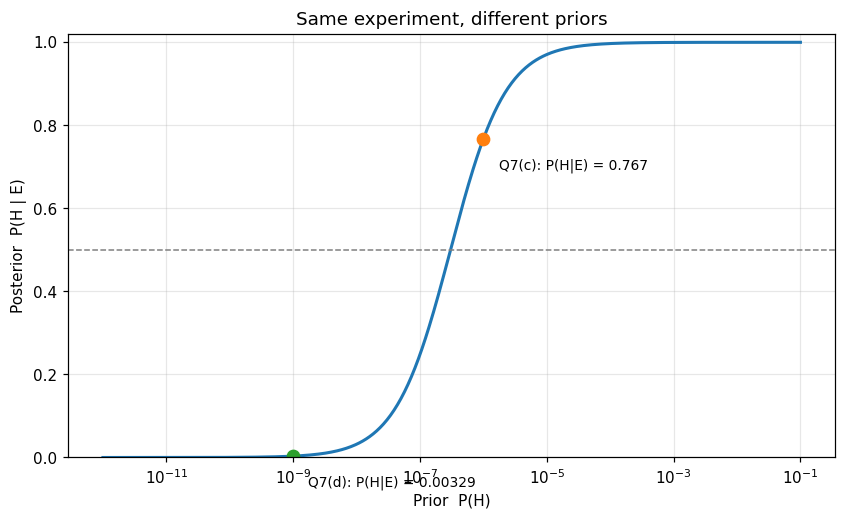

In [5]:
priors = np.logspace(-12, -1, 600)
post = posterior(priors, sens0, fpr0)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(priors, post, lw=2)
ax.set_xscale("log")
ax.set_ylim(0, 1.02)

for p, name in [(1e-6, "Q7(c)"), (1e-9, "Q7(d)")]:
    y = posterior(p, sens0, fpr0)
    ax.plot(p, y, "o", ms=8)
    ax.annotate(f"{name}: P(H|E) = {y:.3g}", (p, y),
                textcoords="offset points", xytext=(10, -20), fontsize=9)

ax.axhline(0.5, color="gray", ls="--", lw=1)
ax.set_xlabel("Prior  P(H)")
ax.set_ylabel("Posterior  P(H | E)")
ax.set_title("Same experiment, different priors")
plt.show()

The experiment never changed, yet the posterior goes from near 1 to near 0 purely because the prior changed.

The dashed line marks 50%. Setting $P(H\mid E)=0.5$ in the formula and solving for the prior gives the exact break-even prior:

$$P(H)=\frac{P(E\mid\neg H)}{P(E\mid H)+P(E\mid\neg H)}$$

In [6]:
p_half = fpr0 / (sens0 + fpr0)
print(f"Prior needed for P(H|E) = 0.5:  {p_half:.4e}")

Prior needed for P(H|E) = 0.5:  3.0303e-07


## Fix the prior, how accurate must the measurement be?

Fix $P(H)$ and ask for $P(H\mid E) > q$ with $q = 0.75$. Write $s = P(E\mid H)$ and $f = P(E\mid\neg H)$. Start from

$$q = \frac{s\,P(H)}{s\,P(H) + f\,\big(1-P(H)\big)}$$

and solve for $f$:

$$f_{\max} = \frac{s\,P(H)\,(1-q)}{q\,\big(1-P(H)\big)}$$

Any measurement with $f < f_{\max}$ (for its sensitivity $s$) gives a posterior above $q$. For $q = 0.75$ the factor $\frac{1-q}{q}$ is $\frac{1}{3}$, so

$$f_{\max} = \frac{s\,P(H)}{3\,\big(1-P(H)\big)}$$

Two things follow directly from this formula. First, $f_{\max}$ grows in proportion to $s$, but $s \le 1$, so sensitivity can help by only a limited amount. Second, $f_{\max}$ is proportional to $P(H)$, so a prior 1000 times smaller requires a false-positive rate 1000 times smaller.

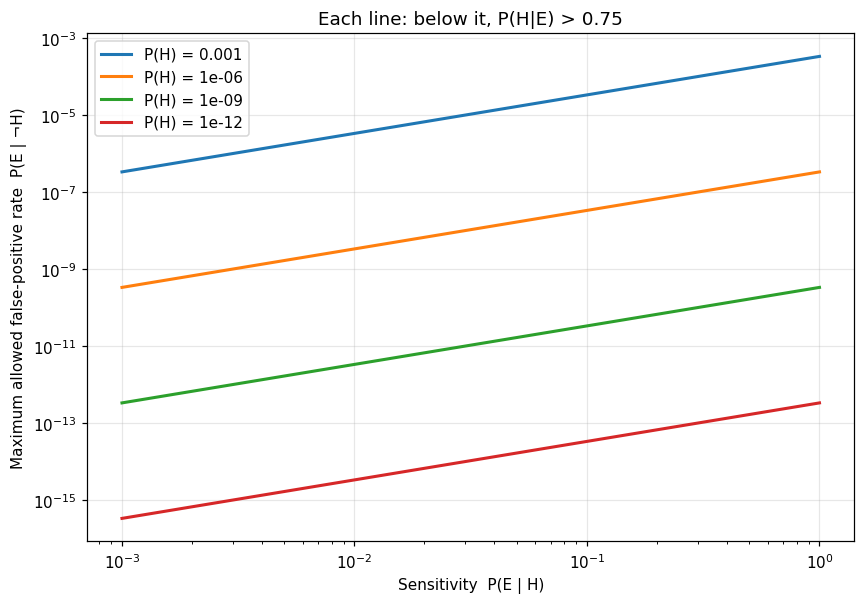

,P(H),max P(E|¬H) for P(H|E) > 0.75 (s=0.99)
0,1.000e-03,3.303e-04
1,1.000e-06,3.300e-07
2,1.000e-09,3.300e-10
3,1.000e-12,3.300e-13


In [9]:
q = 0.75

def max_fpr(prior, sens, q):
    # largest P(E|~H) that still gives P(H|E) = q, for a given sensitivity
    return sens * prior * (1 - q) / (q * (1 - prior))

sens_axis = np.logspace(-3, 0, 300)

fig, ax = plt.subplots(figsize=(9, 6))
for prior in [1e-3, 1e-6, 1e-9, 1e-12]:
    ax.plot(sens_axis, max_fpr(prior, sens_axis, q), lw=2, label=f"P(H) = {prior:g}")

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Sensitivity  P(E | H)")
ax.set_ylabel("Maximum allowed false-positive rate  P(E | ¬H)")
ax.set_title(f"Each line: below it, P(H|E) > {q}")
ax.legend()
plt.show()

# table at sensitivity 0.99
rows = [{"P(H)": p, "max P(E|¬H) for P(H|E) > 0.75 (s=0.99)": max_fpr(p, 0.99, q)}
        for p in [1e-3, 1e-6, 1e-9, 1e-12]]
pd.DataFrame(rows).style.format("{:.3e}")

## 4. Grid: prior and sensitivity

False-positive rate fixed at $3\times10^{-7}$. Colour is $P(H\mid E)$. White contour: 50%. Dashed black contour: 90%.

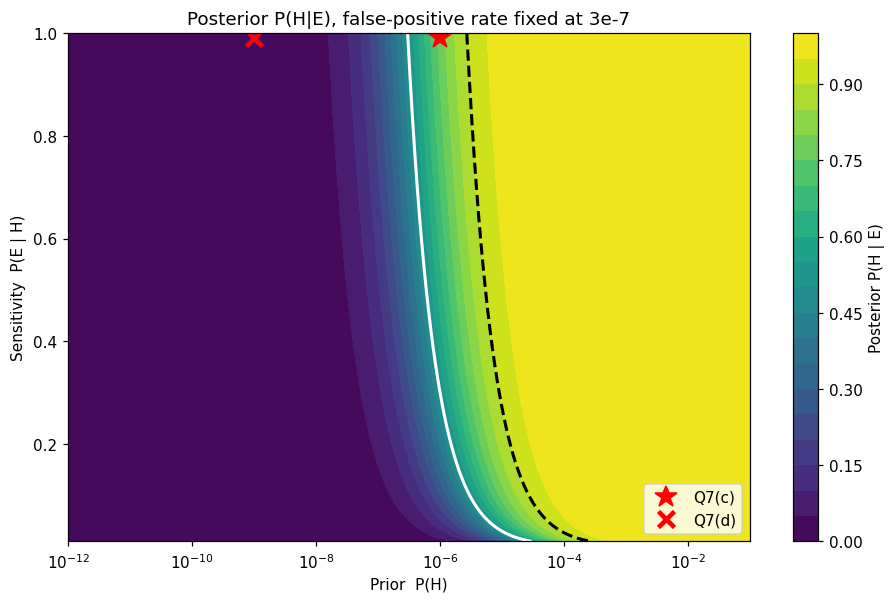

In [10]:
p_grid = np.logspace(-12, -1, 300)
s_grid = np.linspace(0.01, 1.0, 300)
P, S = np.meshgrid(p_grid, s_grid)
Z = posterior(P, S, fpr0)

fig, ax = plt.subplots(figsize=(10, 6))
cf = ax.contourf(P, S, Z, levels=np.linspace(0, 1, 21), cmap="viridis")
ax.contour(P, S, Z, levels=[0.5], colors="white", linewidths=2)
ax.contour(P, S, Z, levels=[0.9], colors="black", linewidths=2, linestyles="--")
ax.plot(prior0, sens0, "r*", ms=15, label="Q7(c)")
ax.plot(1e-9, sens0, "rx", ms=10, mew=3, label="Q7(d)")
ax.set_xscale("log"); ax.grid(False)
ax.set_xlabel("Prior  P(H)")
ax.set_ylabel("Sensitivity  P(E | H)")
ax.set_title("Posterior P(H|E), false-positive rate fixed at 3e-7")
fig.colorbar(cf, label="Posterior P(H | E)")
ax.legend(loc="lower right")
plt.show()

The contours are nearly vertical: changing the sensitivity moves the posterior very little, while changing the prior moves it completely. Sensitivity answers "if $H$ is true, do we detect it?", not "given a detection, is $H$ true?".

## 5. Grid: prior and false-positive rate

Sensitivity fixed at $0.99$.

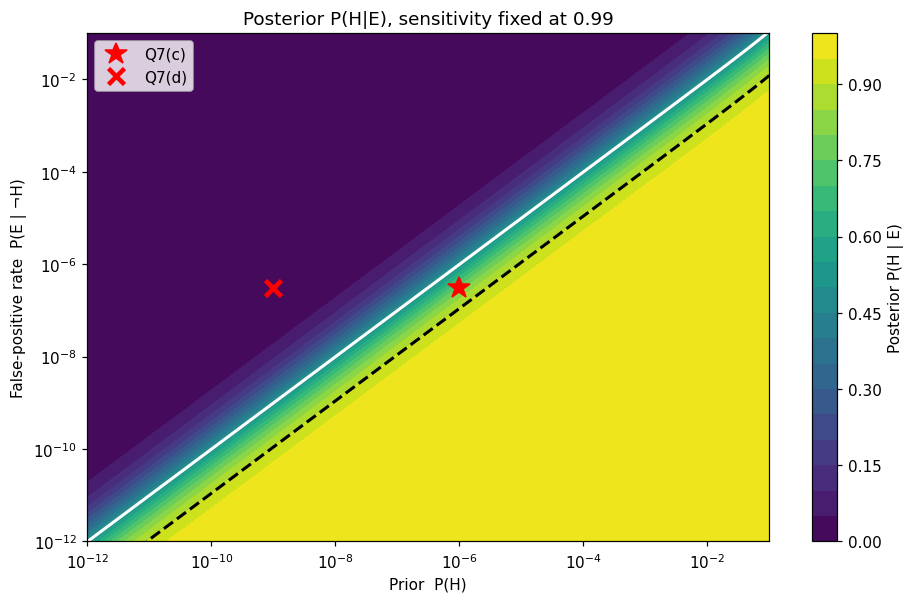

In [11]:
f_grid = np.logspace(-12, -1, 300)
P, F = np.meshgrid(p_grid, f_grid)
Z = posterior(P, sens0, F)

fig, ax = plt.subplots(figsize=(10, 6))
cf = ax.contourf(P, F, Z, levels=np.linspace(0, 1, 21), cmap="viridis")
ax.contour(P, F, Z, levels=[0.5], colors="white", linewidths=2)
ax.contour(P, F, Z, levels=[0.9], colors="black", linewidths=2, linestyles="--")
ax.plot(prior0, fpr0, "r*", ms=15, label="Q7(c)")
ax.plot(1e-9, fpr0, "rx", ms=10, mew=3, label="Q7(d)")
ax.set_xscale("log"); ax.set_yscale("log"); ax.grid(False)
ax.set_xlabel("Prior  P(H)")
ax.set_ylabel("False-positive rate  P(E | ¬H)")
ax.set_title("Posterior P(H|E), sensitivity fixed at 0.99")
fig.colorbar(cf, label="Posterior P(H | E)")
ax.legend(loc="upper left")
plt.show()

Here the contours are diagonal. When the prior gets smaller, the false-positive rate has to get smaller by the same factor to keep the same posterior. Q7(d) sits in the "doubt" region.

## 6. What prior leaves doubt, even for a precise experiment?

Solving $P(H\mid E)=q$ exactly for the prior, with $s=P(E\mid H)$ and $f=P(E\mid\neg H)$:

$$P(H)=\frac{q\,f}{s\,(1-q)+q\,f}$$

Any prior below this value leaves the posterior below $q$ after a positive result.

In [12]:
def prior_for_posterior(q, sens, fpr):
    return q * fpr / (sens * (1 - q) + q * fpr)

targets = [0.5, 0.9, 0.99]
rows = []
for fpr in [1e-3, 1e-4, 1e-6, 3e-7, 1e-9, 1e-12]:
    row = {"P(E|¬H)": fpr}
    for q in targets:
        row[f"prior needed for P(H|E)={q}"] = prior_for_posterior(q, 0.99, fpr)
    rows.append(row)

pd.DataFrame(rows).style.format("{:.2e}")

,P(E|¬H),prior needed for P(H|E)=0.5,prior needed for P(H|E)=0.9,prior needed for P(H|E)=0.99
0,1.00e-03,1.01e-03,9.01e-03,9.09e-02
1,1.00e-04,1.01e-04,9.08e-04,9.90e-03
2,1.00e-06,1.01e-06,9.09e-06,1.00e-04
3,3.00e-07,3.03e-07,2.73e-06,3.00e-05
4,1.00e-09,1.01e-09,9.09e-09,1.00e-07
5,1.00e-12,1.01e-12,9.09e-12,1.00e-10


## 7. Try it: change one input at a time

In [13]:
prior, sens, fpr = 1e-9, 0.99, 3e-7   # change these and re-run

print(f"P(H|E) = {posterior(prior, sens, fpr):.6f}")

P(H|E) = 0.003289


In [14]:
base = dict(prior=1e-9, sens=0.99, fpr=3e-7)
cases = {
    "baseline (Q7d)":                base,
    "sensitivity 0.99 -> 0.9999":    {**base, "sens": 0.9999},
    "false-positive rate 100x smaller": {**base, "fpr": 3e-9},
    "prior 1000x larger":            {**base, "prior": 1e-6},
}
pd.DataFrame(
    [{"case": k, "P(H|E)": posterior(**v)} for k, v in cases.items()]
).style.format({"P(H|E)": "{:.5f}"})

,case,P(H|E)
0,baseline (Q7d),0.00329
1,sensitivity 0.99 -> 0.9999,0.00332
2,false-positive rate 100x smaller,0.24812
3,prior 1000x larger,0.76744


## Takeaway

Accuracy of the measurement does not equal certainty of the conclusion. The posterior depends on all three inputs, and when the prior is tiny, the false positives (from the huge pool of cases where $H$ is false) outnumber the true positives, even for a very accurate experiment.

## Q7 Solution

**(a)**

$$P(H \mid E) = \frac{P(E \mid H)\,P(H)}{P(E \mid H)\,P(H) + P(E \mid \neg H)\,P(\neg H)}$$

**(b)**

$$
\begin{aligned}
P(E) &= P(E \mid H)\,P(H) + P(E \mid \neg H)\,P(\neg H) \\
&= 0.99\,(10^{-6}) + (3\times10^{-7})\,(1 - 10^{-6}) \\
&= 9.9\times10^{-7} + 3.0\times10^{-7} \approx 1.29\times10^{-6}
\end{aligned}
$$

**(c)**

$$P(H \mid E) = \frac{9.9\times10^{-7}}{1.29\times10^{-6}} \approx 0.767$$

**(d)**

With $P(H) = 10^{-9}$:

$$
\begin{aligned}
P(E) &= 0.99\,(10^{-9}) + (3\times10^{-7})\,(1 - 10^{-9}) \\
&\approx 9.9\times10^{-10} + 3.0\times10^{-7} \approx 3.01\times10^{-7}
\end{aligned}
$$

$$P(H \mid E) = \frac{9.9\times10^{-10}}{3.01\times10^{-7}} \approx 0.00329 \quad (\text{about } 0.33\%)$$

The prior is so tiny that even a small false-positive rate produces far more false alarms than true detections. About 300 false positives occur for every 1 true positive. A positive result from an accurate test therefore says little when the event is extremely rare (the base-rate effect).